# Coastwide 5-km primary analysis audit

## tl;dr

- The 5-km panel contains 368 stable coastal cells and 5522 eligible forecast cell-years.
- Current canopy alone produced a Logistic macro within-year AP lift of 0.153.
- Trajectory added +0.038 (95% year-block CI +0.020 to +0.057); all three fixed model families supported a positive increment.
- OISST added -0.017 (95% CI -0.038 to +0.004) and was not supported. No positive OISST point estimate appeared in the nine locked label/eligibility variants.
- All independent validation checks passed. This is a pilot-informed robustness analysis, not independent confirmation.

## Context & Methods

This analysis asks whether the original coastwide ranking result survives a finer 5-km support while retaining a deployment-aligned evaluation. Information blocks are added in a fixed order: current canopy, trajectory, OISST, and CUTI/BEUTI where supported.

### Key assumptions

- The prediction target is a next-year relative canopy decline, not a validated ecological-collapse threshold.
- Expanding-window predictions and macro within-year AP lift are primary because monitoring ranks cells within each deployment year.
- All feature-block comparisons use identical rows inside their stated support domain.
- OISST and CUTI/BEUTI are operational public proxies, not direct causal measurements.
- The 5-km grid reduces spatial aggregation but does not eliminate grid-origin sensitivity or overlapping ecological processes.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'outputs').exists() and (ROOT.parent / 'outputs').exists():
    ROOT = ROOT.parent
RUN = ROOT / 'outputs/experiments/20260816_coastwide_5km_primary_v1'
assert (RUN / 'manifest.json').exists()

audit = json.loads((RUN / 'input_audit.json').read_text(encoding='utf-8'))
quality = pd.read_csv(RUN / 'data_quality_profile.csv')
protocol = pd.read_csv(RUN / 'protocol_comparison.csv')
summary = pd.read_csv(RUN / 'model_family_summary.csv')
increments = pd.read_csv(RUN / 'model_family_increment_summary.csv')
budget = pd.read_csv(RUN / 'budget_summary.csv')
sensitivity = pd.read_csv(RUN / 'sensitivity_increment_summary.csv')
validation = pd.read_csv(RUN / 'validation_recheck.csv')
assert validation['passed'].all()
print('Loaded', RUN.relative_to(ROOT))
print('Validation:', int(validation['passed'].sum()), '/', len(validation))

Loaded outputs/experiments/20260816_coastwide_5km_primary_v1
Validation: 28 / 28


## Data

In [2]:
pd.DataFrame([audit]).T.rename(columns={0: 'value'})

,value
spec_id,g05_area_scaled_o00
cells,368
cell_years,15456
year_min,1984
year_max,2025
duplicate_panel_keys,0
duplicate_environment_keys,0
eligible_forecast_rows,5522
forecast_events,2231
oisst_supported_cells,361


In [3]:
quality

,check,value
0,panel_rows,15456
1,panel_cells,368
2,panel_year_min,1984
3,panel_year_max,2025
4,panel_duplicate_keys,0
5,environment_rows,15456
6,environment_duplicate_keys,0
7,merged_rows,15456
8,primary_eligible_rows,9659
9,primary_eligible_cells,368


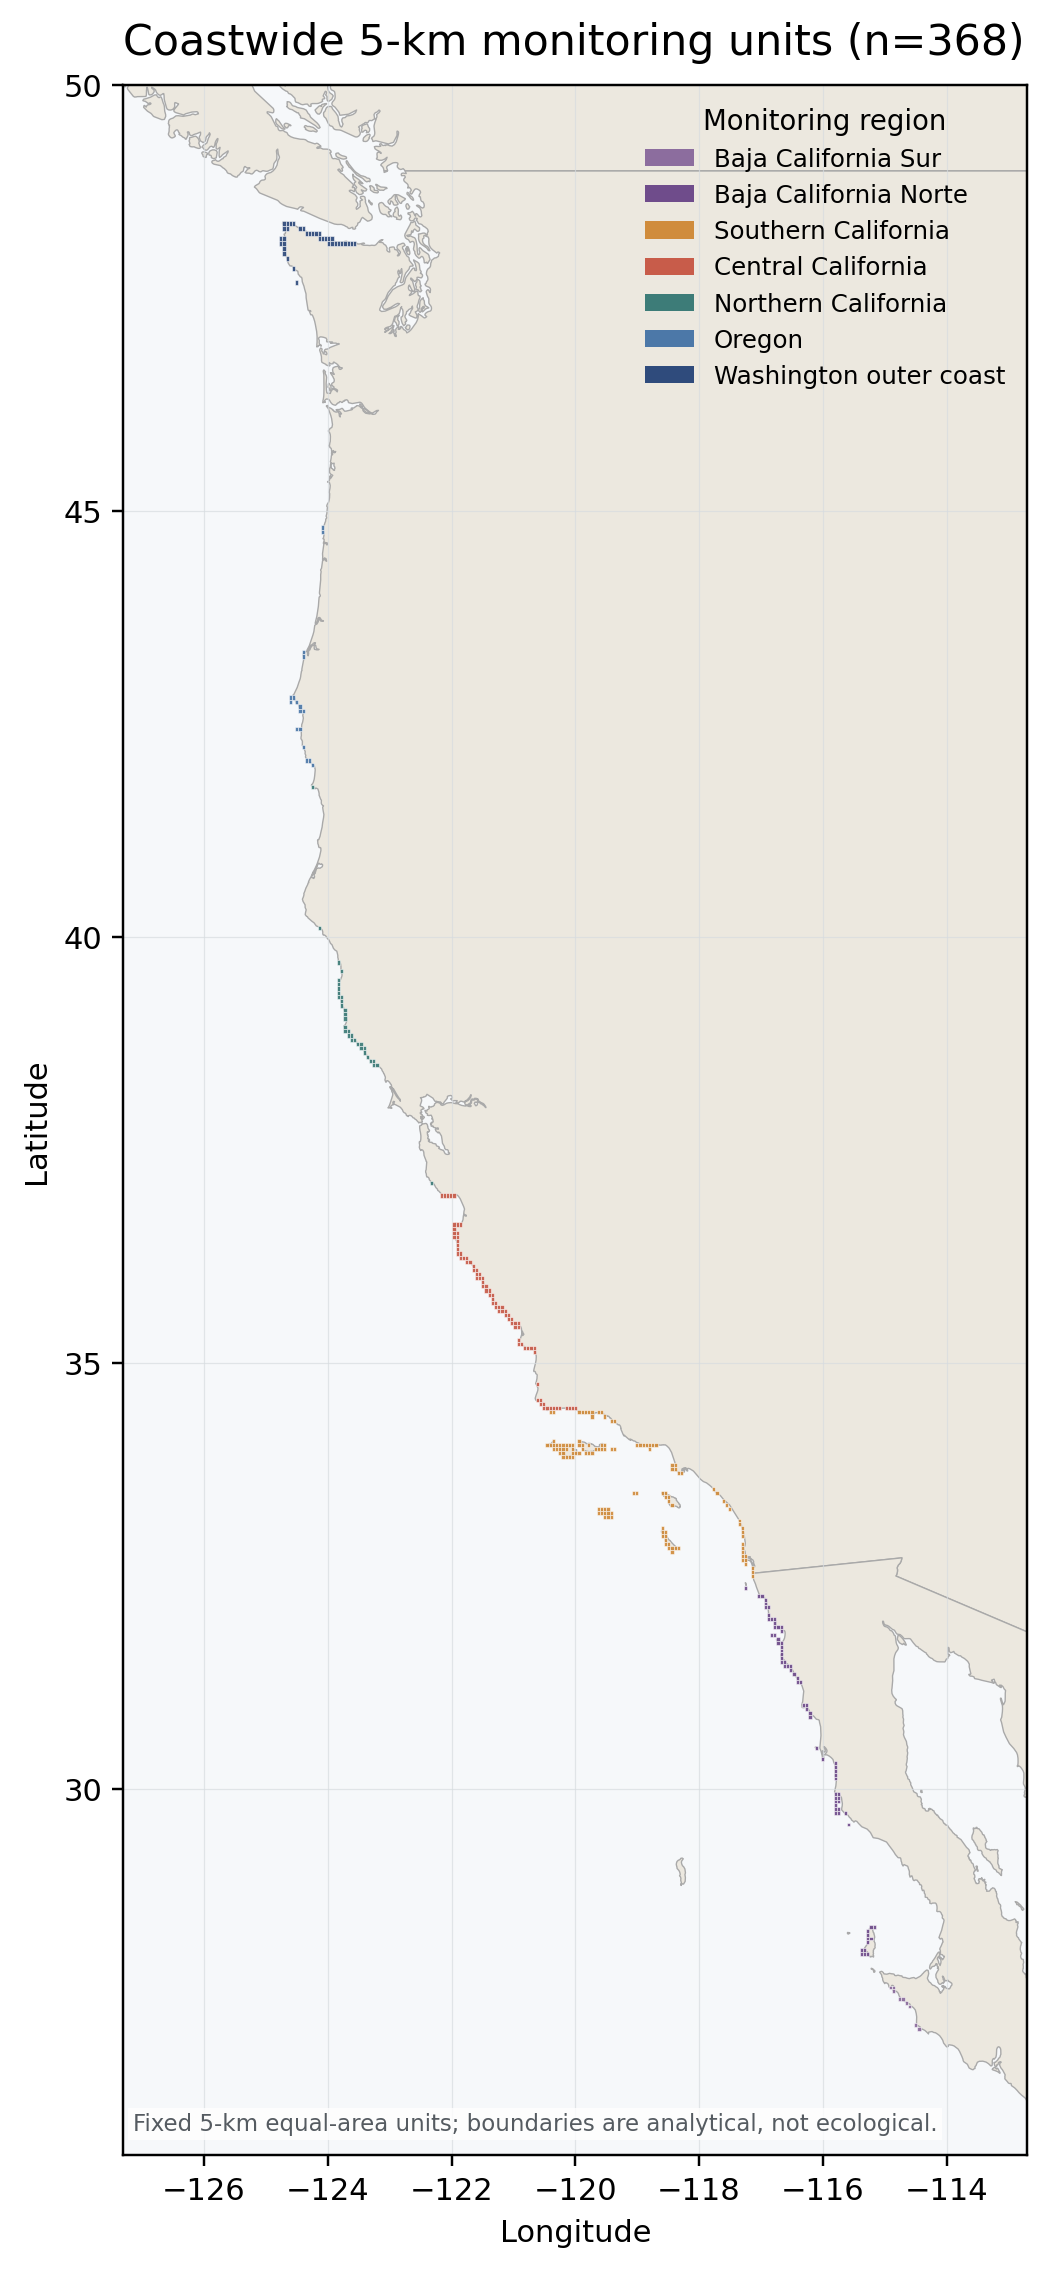

In [4]:
display(Image(filename=str(RUN / 'figure_00_5km_grid_map.png')))

The intended grain is one stable 5-km cell-year. OISST and upwelling comparisons use their own fixed supported domains, so a larger feature set never receives credit merely by changing its evaluation sample.

## Results

### 1. Evaluation protocol

In [5]:
protocol.round(4)

,domain,feature_set,feature_label,random_repeats,random_pooled_mean,random_pooled_p025,random_pooled_p975,expanding_pooled,random_minus_expanding_pooled,random_macro_within_year_mean,random_macro_within_year_p025,random_macro_within_year_p975,expanding_macro_within_year,random_minus_expanding_macro_within_year
0,full_oisst_domain,current_only,Current,20,0.1642,0.1634,0.1646,0.1597,0.0045,0.1530,0.1524,0.1534,0.1530,-0.0000
1,full_oisst_domain,current_plus_trajectory,Current + trajectory,20,0.1962,0.1950,0.1968,0.1848,0.0113,0.1975,0.1962,0.1983,0.1909,0.0065
2,full_oisst_domain,trajectory_plus_oisst,Current + trajectory + OISST,20,0.1976,0.1962,0.1986,0.1665,0.0312,0.1907,0.1891,0.1917,0.1739,0.0168
3,upwelling_supported_domain,current_only,Current,20,0.1577,0.1572,0.1582,0.1507,0.0070,0.1402,0.1391,0.1422,0.1401,0.0001
4,upwelling_supported_domain,current_plus_trajectory,Current + trajectory,20,0.1820,0.1813,0.1831,0.1640,0.0180,0.1795,0.1780,0.1809,0.1679,0.0116
5,upwelling_supported_domain,trajectory_plus_oisst,Current + trajectory + OISST,20,0.1870,0.1854,0.1885,0.1434,0.0437,0.1761,0.1741,0.1775,0.1632,0.0129
6,upwelling_supported_domain,trajectory_plus_oisst_cuti_beuti,Current + trajectory + OISST + CUTI/BEUTI,20,0.2019,0.2006,0.2034,0.1348,0.0671,0.1673,0.1651,0.1694,0.1542,0.0131


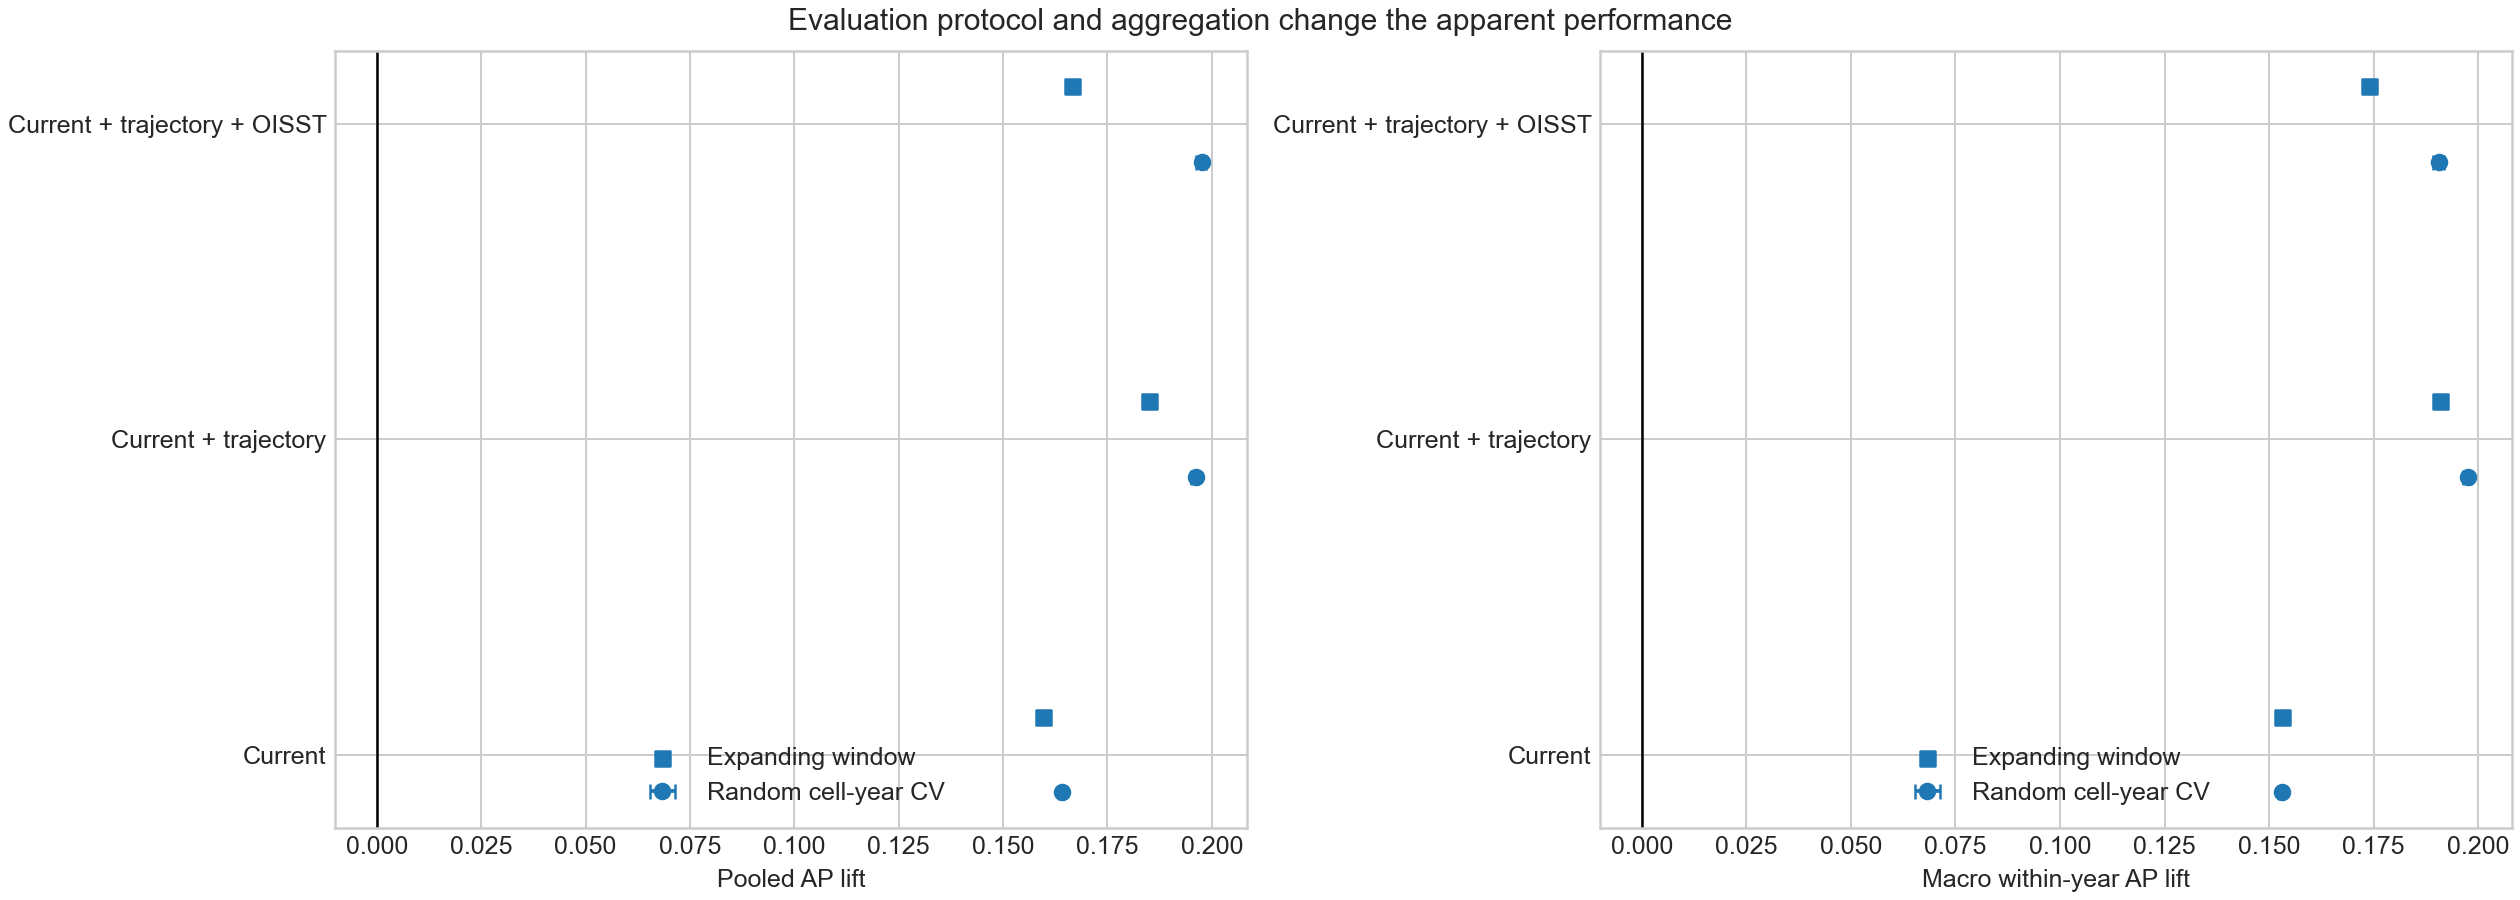

In [6]:
display(Image(filename=str(RUN / 'figure_01_protocol_comparison.png')))

### 2. Information-block increments across model families

In [7]:
increments[['domain', 'model_label', 'comparison', 'estimate', 'ci_low', 'ci_high']].round(4)

,domain,model_label,comparison,estimate,ci_low,ci_high
0,full_oisst_domain,Logistic,trajectory_minus_current,0.0379,0.0196,0.0568
1,full_oisst_domain,Logistic,oisst_minus_trajectory,-0.0170,-0.0379,0.0035
2,full_oisst_domain,Random forest,trajectory_minus_current,0.0419,0.0272,0.0572
3,full_oisst_domain,Random forest,oisst_minus_trajectory,0.0022,-0.0103,0.0147
4,full_oisst_domain,XGBoost,trajectory_minus_current,0.0331,0.0203,0.0485
5,full_oisst_domain,XGBoost,oisst_minus_trajectory,0.0154,-0.0072,0.0374
6,upwelling_supported_domain,Logistic,trajectory_minus_current,0.0278,0.0064,0.0503
7,upwelling_supported_domain,Logistic,oisst_minus_trajectory,-0.0047,-0.0206,0.0113
8,upwelling_supported_domain,Logistic,cuti_beuti_minus_oisst,-0.0090,-0.0243,0.0057
9,upwelling_supported_domain,Random forest,trajectory_minus_current,0.0335,0.0123,0.0567


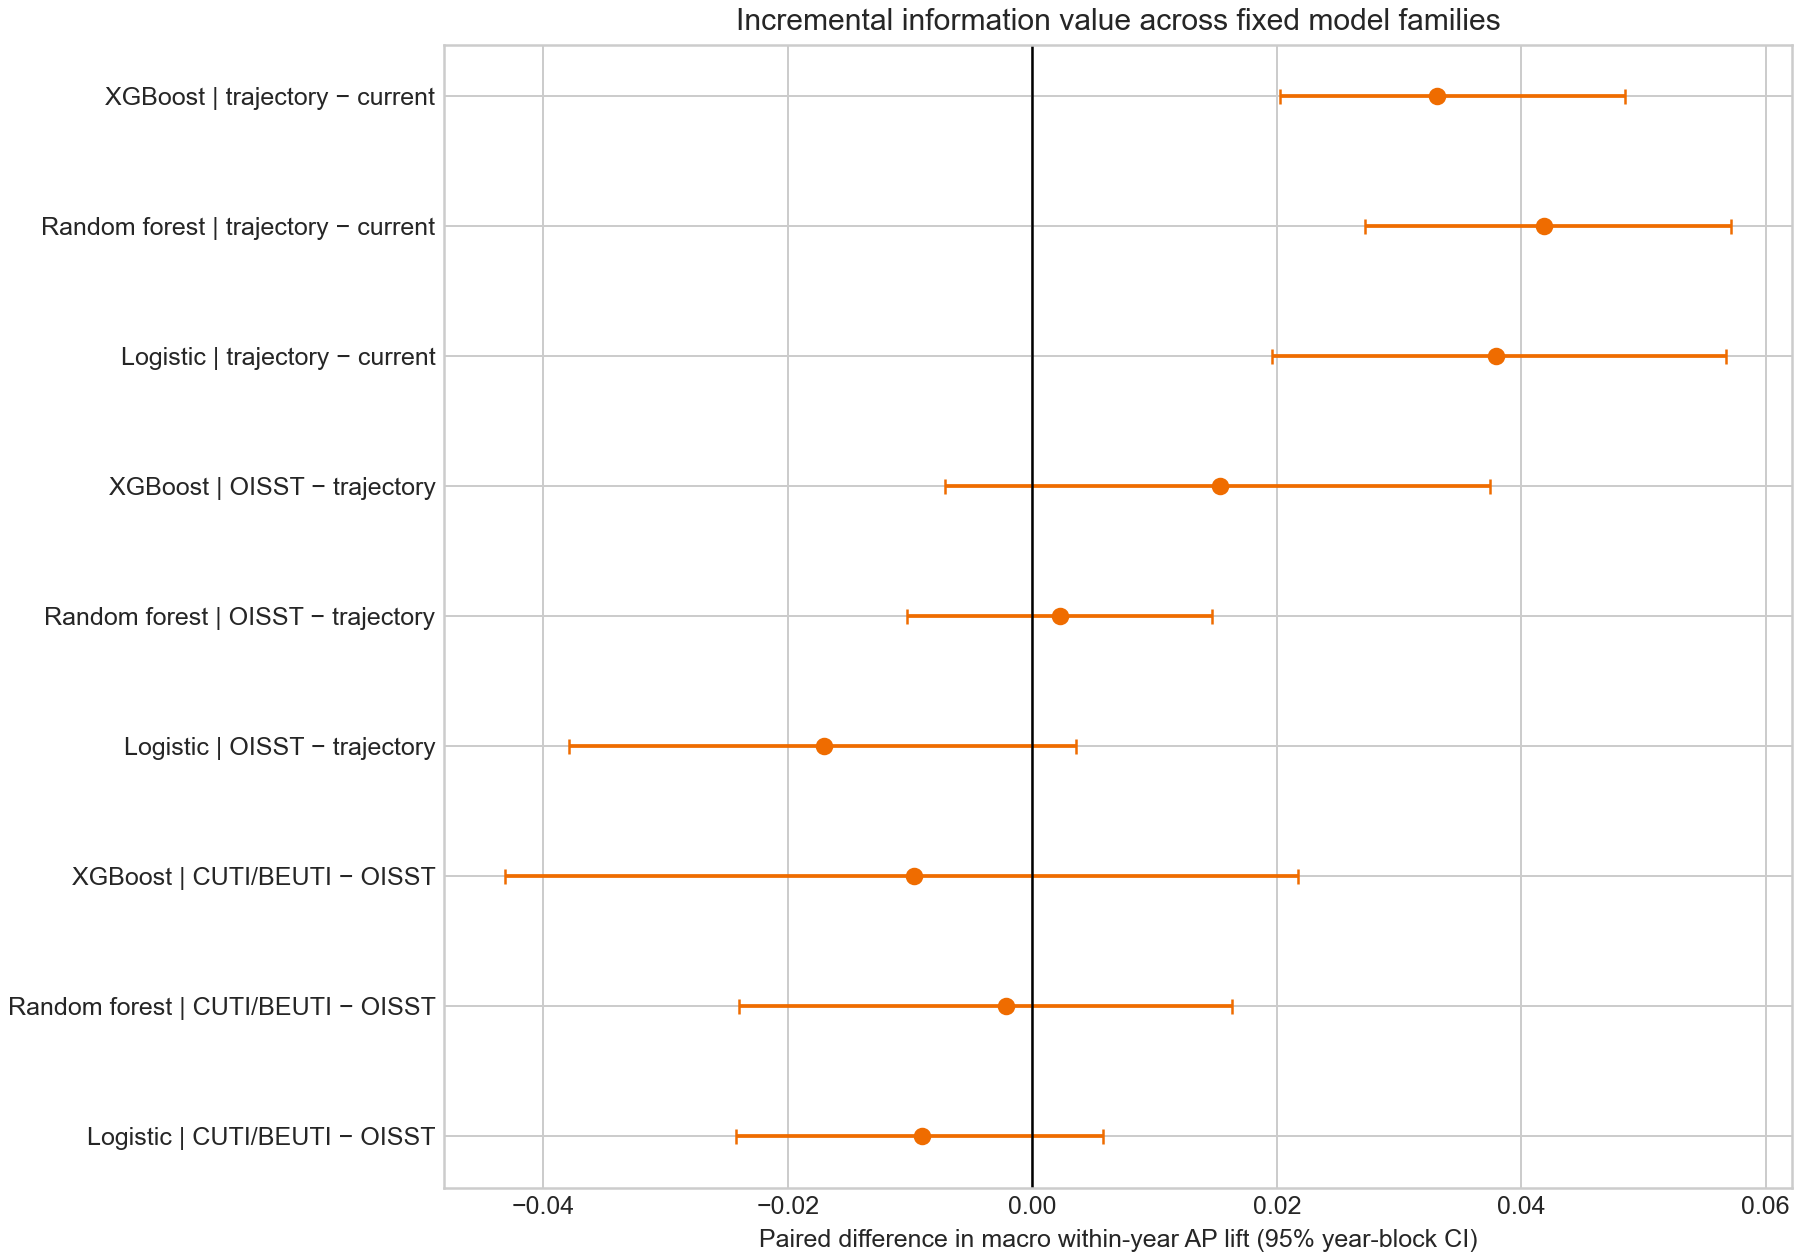

In [8]:
display(Image(filename=str(RUN / 'figure_02_model_family_increments.png')))

At 5 km, the trajectory increment is positive in Logistic, Random Forest, and XGBoost. Neither public environmental block has a confidence interval supporting a positive increment in any fixed family.

### 3. Monitoring-budget trade-off

In [9]:
budget[['feature_set', 'budget_fraction', 'micro_recall', 'recall_ci_low', 'recall_ci_high']].round(4)

,feature_set,budget_fraction,micro_recall,recall_ci_low,recall_ci_high
0,current_only,0.05,0.0884,0.0757,0.1051
1,current_only,0.10,0.1703,0.1494,0.1977
2,current_only,0.20,0.2967,0.2726,0.3282
3,current_only,0.30,0.4089,0.3857,0.4391
4,current_plus_trajectory,0.05,0.0962,0.0829,0.1156
...,...,...,...,...,...
79,trajectory_plus_oisst,0.30,0.3973,0.3640,0.4451
80,trajectory_plus_oisst_cuti_beuti,0.05,0.0807,0.0629,0.1054
81,trajectory_plus_oisst_cuti_beuti,0.10,0.1580,0.1319,0.1950
82,trajectory_plus_oisst_cuti_beuti,0.20,0.2820,0.2495,0.3268


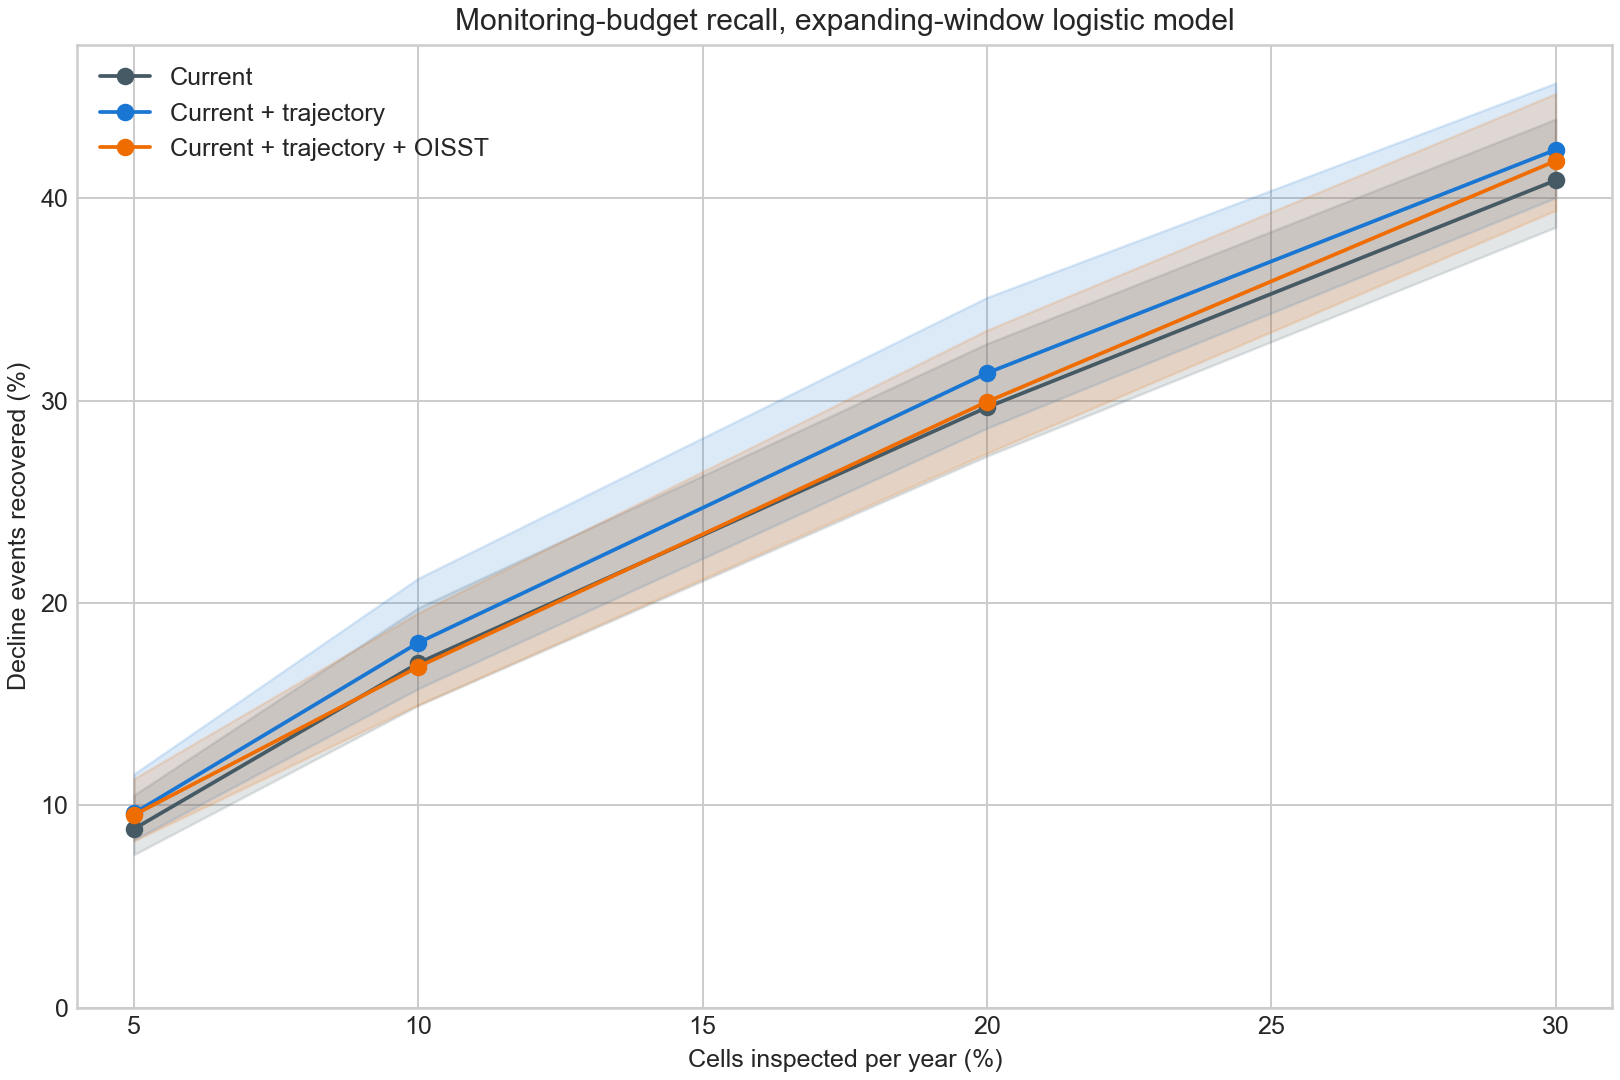

In [10]:
display(Image(filename=str(RUN / 'figure_03_budget_recall_curve.png')))

### 4. Outcome and eligibility sensitivity

In [11]:
sensitivity.round(4)

,decline_threshold,canopy_cutoff,domain,comparison,estimate,ci_low,ci_high,estimable_years
0,0.2,0.02,full_oisst_domain,trajectory_minus_current,0.0277,0.0146,0.0433,20
1,0.2,0.02,full_oisst_domain,oisst_minus_trajectory,-0.0113,-0.0283,0.0045,20
2,0.2,0.02,upwelling_supported_domain,trajectory_minus_current,0.0219,0.0057,0.0400,20
3,0.2,0.02,upwelling_supported_domain,oisst_minus_trajectory,-0.0043,-0.0164,0.0078,20
4,0.2,0.02,upwelling_supported_domain,cuti_beuti_minus_oisst,-0.0098,-0.0218,0.0018,20
5,0.2,0.05,full_oisst_domain,trajectory_minus_current,0.0295,0.0154,0.0449,20
6,0.2,0.05,full_oisst_domain,oisst_minus_trajectory,-0.0113,-0.0272,0.0044,20
7,0.2,0.05,upwelling_supported_domain,trajectory_minus_current,0.0218,0.0045,0.0412,20
8,0.2,0.05,upwelling_supported_domain,oisst_minus_trajectory,-0.0034,-0.0164,0.0091,20
9,0.2,0.05,upwelling_supported_domain,cuti_beuti_minus_oisst,-0.0086,-0.0221,0.0034,20


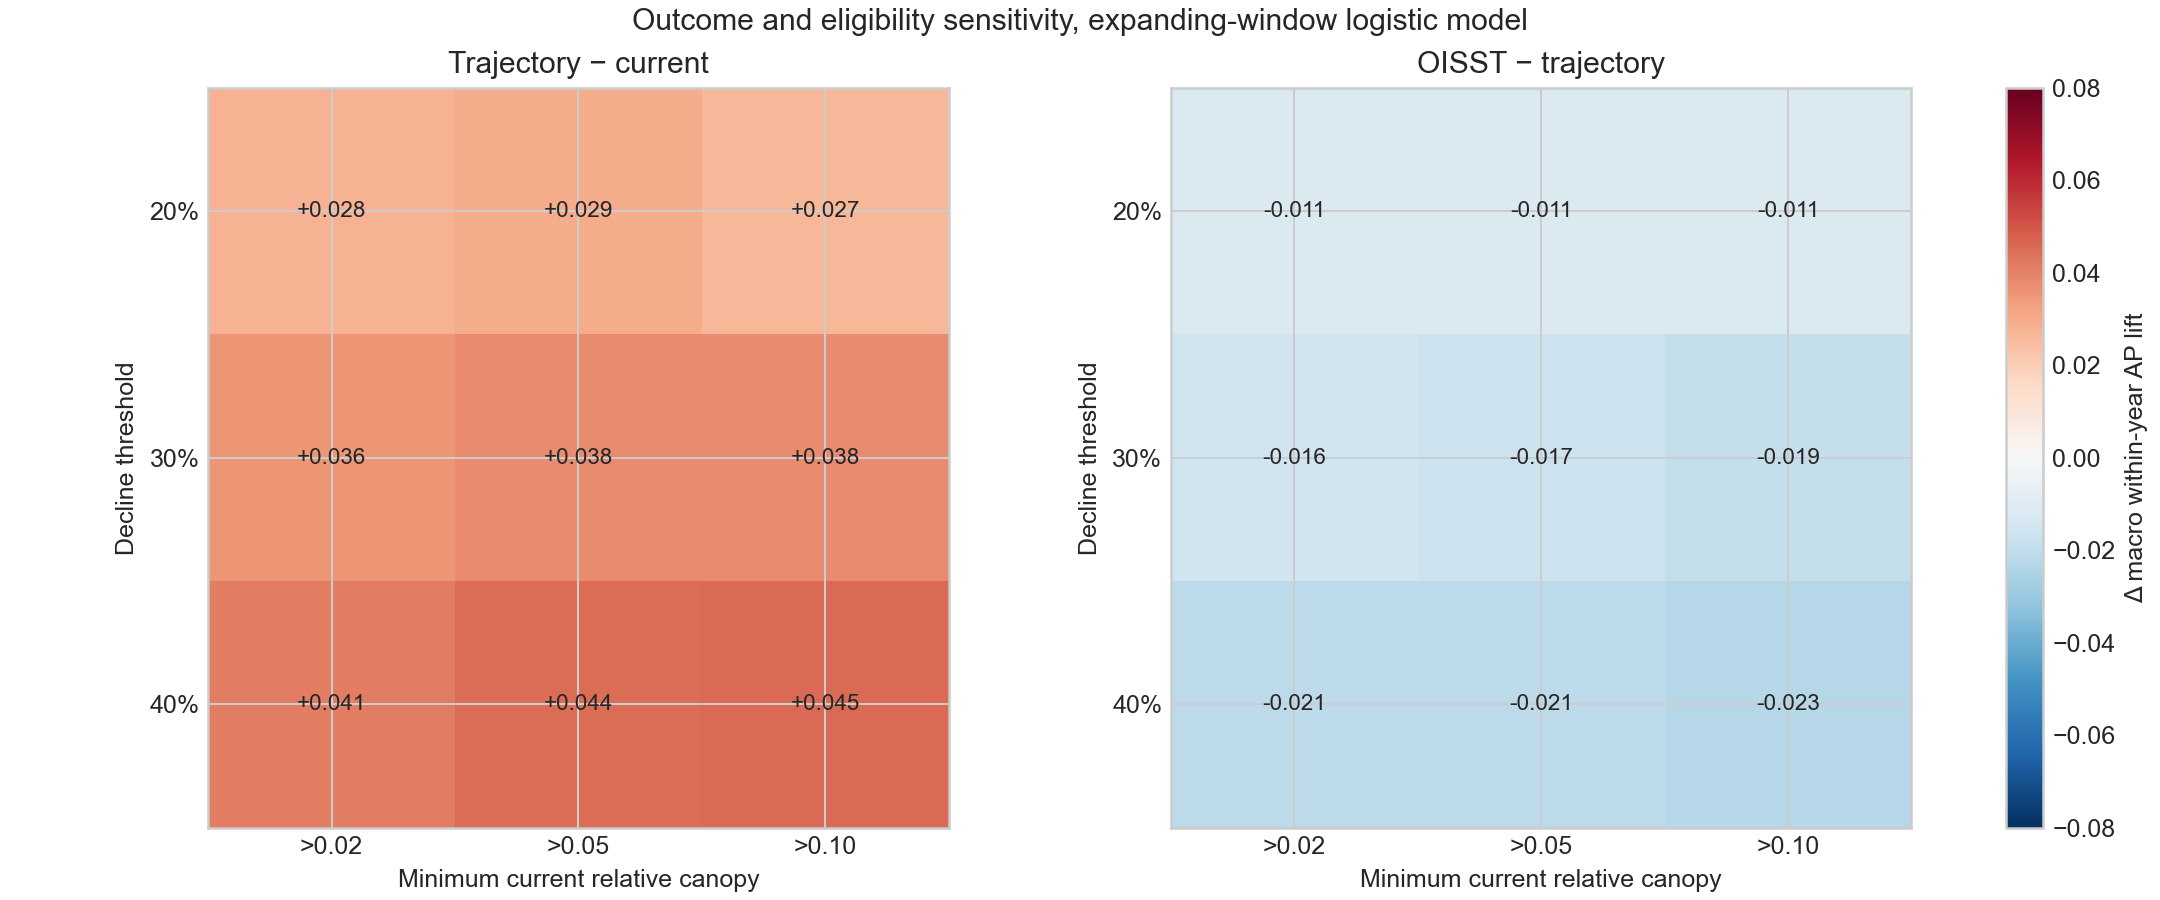

In [12]:
display(Image(filename=str(RUN / 'figure_04_threshold_canopy_sensitivity.png')))

## Takeaways

1. The coastwide decision-support claim survives the finer 5-km support.
2. Recent canopy trajectory is a small, model-robust secondary block at 5 km.
3. OISST and CUTI/BEUTI do not add demonstrated ranking value after canopy history under the locked timing and support rules.
4. The negative proxy result must not be rewritten as evidence that temperature or upwelling are ecologically irrelevant.
5. Grid-origin sensitivity remains a warning against interpreting any single top-priority cell boundary as uniquely correct.